# Probabilidade - Tarefa

In [2]:
import math
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn           as sns

from scipy import stats

1. Uma máquina embala ração para cachorro em pacotes de 15 kg, mas cada pacote produzido acaba tendo um peso aleatório, com distribuição Normal, com média 15kg, mas com desvio padrão 0,1 kg. Obtenha a probabilidade de que um pacote selecionado aleatoriamente dessa produção tenha mais que 15,2 kg.

In [4]:
# Parâmetros da distribuição normal
media = 15  # média em kg
desvio_padrao = 0.1  # desvio padrão em kg

# Valor limite superior (15,2 kg)
limite_superior = 15.2

# Calcular a probabilidade de um pacote ter mais que 15,2 kg usando a função de distribuição acumulativa (CDF)
probabilidade = 1 - stats.norm.cdf(x=limite_superior, loc=media, scale=desvio_padrao)

# Exibe o resultado formatado
print(f'A probabilidade de um pacote ter mais que {limite_superior} kg é de: {probabilidade*100:.2f}%'.replace('.', ','))

A probabilidade de um pacote ter mais que 15,2 kg é de: 2,28%


2. Da máquina descrita acima, obtenha o percentil de ordem 95% para o peso dos pacotes. Ou seja, o valor tal que a probabilidade de um pacote ter peso menor que este seja de 95%.

In [6]:
# Calcula o percentil de ordem 95% para o peso dos pacotes
percentil = stats.norm.ppf(q=0.95, loc=media, scale=desvio_padrao)

# Exibe o resultado formatado
print(f'O percentil de ordem 95% para o peso dos pacotes é: {percentil:.2f} kg'.replace('.', ','))

O percentil de ordem 95% para o peso dos pacotes é: 15,16 kg


3. Suponha duas variáveis aleatórias $Y_1$ e $Y_2$, a primeira com distribuição Normal Padrão (média=0, variância=1), a segunda com distribuição *t-studdent* com 5 graus de liberdade (também padrão). Calcule, para cada uma, a probabilidade de ser menor que cada um dos valores contidos no objeto $Y$ na célula abaixo:

In [8]:
Y = np.linspace(-6, 6, 200)
# Seu código começa aqui

# Parâmetros para Y1 (distribuição normal padrão)
media = 0
variancia = 1
desvio_padrao = math.sqrt(variancia)

# Calcula a probabilidade de Y1 ser menor que cada valor em Y
Y1 = stats.norm.cdf(x=Y, loc=media, scale=desvio_padrao)

# Parâmetros para Y2 (distribuição t-student com 5 graus de liberdade)
graus_de_liberdade = 5

# Calcula a probabilidade de Y2 ser menor que cada valor em Y
Y2 = stats.t.cdf(x=Y, df=graus_de_liberdade)

# Exibe os resultados em um DataFrame
pd.set_option('display.max_rows', 200)
pd.DataFrame(data={'Y':map(lambda x: f'<= {x:.2f}', Y), 
                   'Y1':map(lambda x: f'{round(x*100, 2)}%', Y1), 
                   'Y2':map(lambda x: f'{round(x*100, 2)}%', Y2)})

,Y,Y1,Y2
0,<= -6.00,0.0%,0.09%
1,<= -5.94,0.0%,0.1%
2,<= -5.88,0.0%,0.1%
3,<= -5.82,0.0%,0.11%
4,<= -5.76,0.0%,0.11%
5,<= -5.70,0.0%,0.12%
6,<= -5.64,0.0%,0.12%
7,<= -5.58,0.0%,0.13%
8,<= -5.52,0.0%,0.13%
9,<= -5.46,0.0%,0.14%


4. Faça uma visualização gráfica dos dados do item anterior.

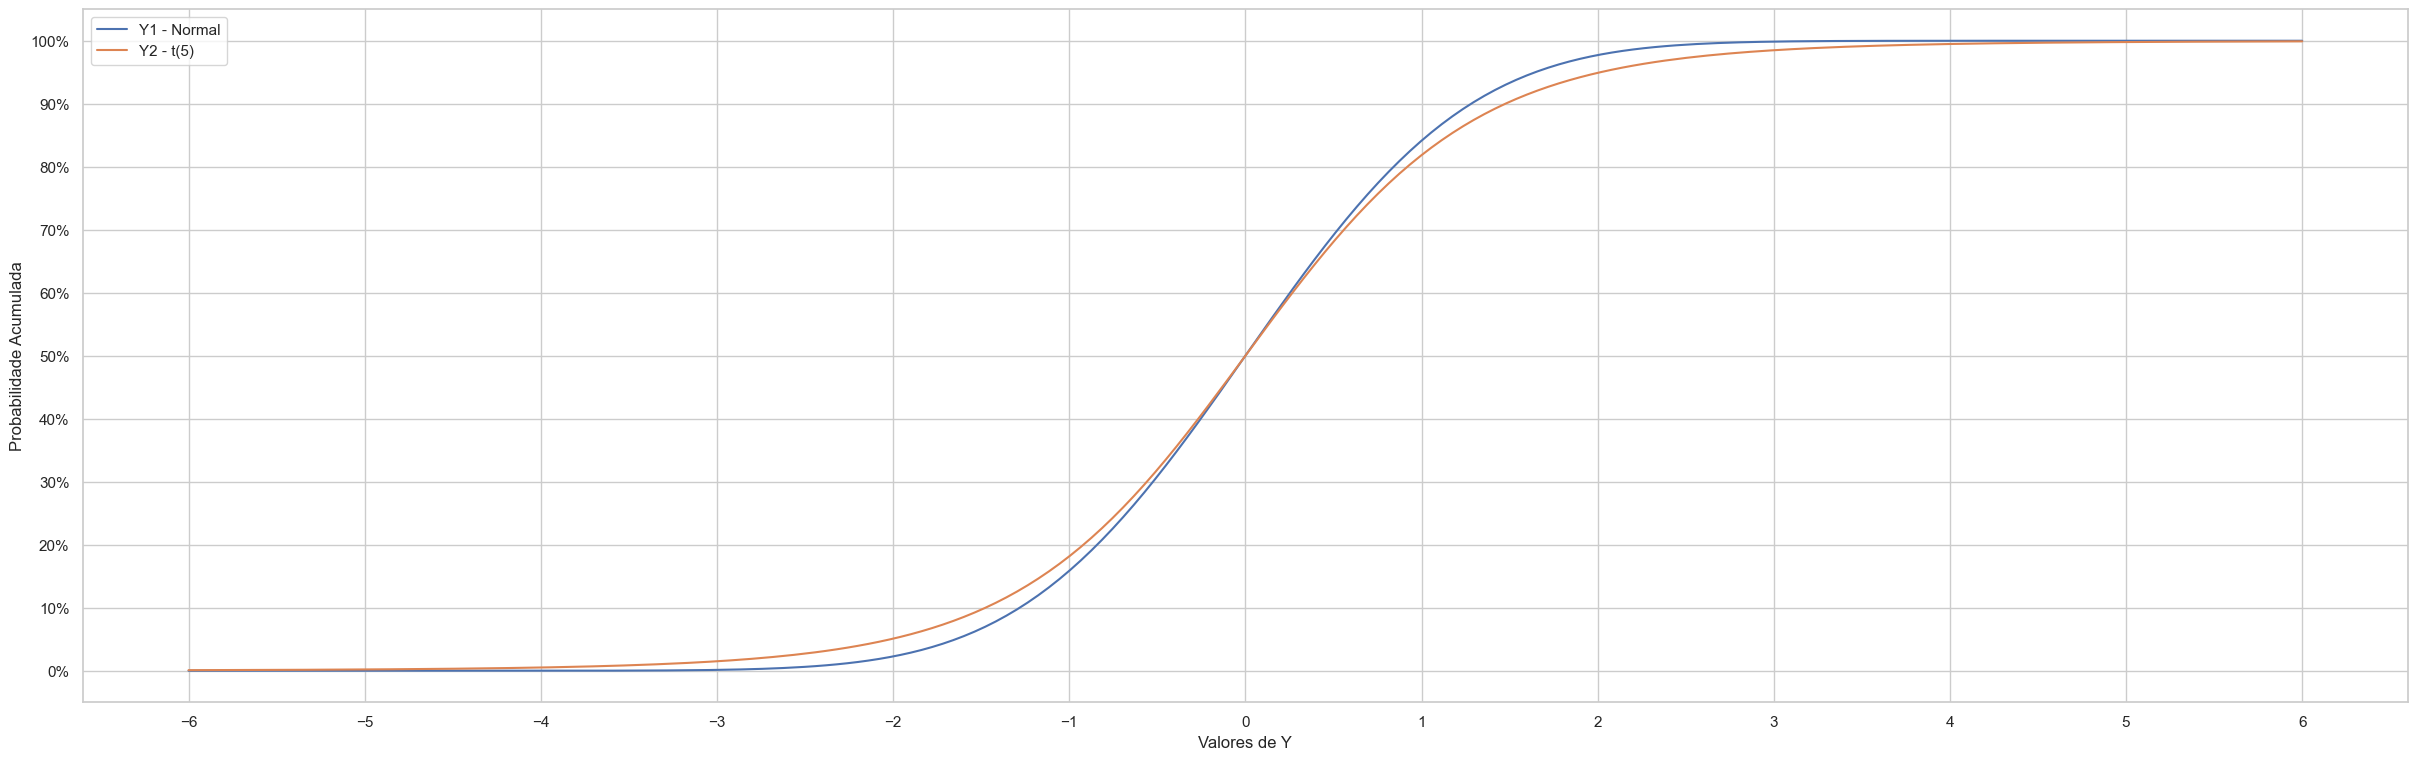

In [10]:
# Configuração do estilo do gráfico
sns.set(style='whitegrid')

# Criação da figura e do eixo
fig, ax = plt.subplots(figsize=(30, 9))

# Plotagem dos dados de Y1 e Y2
ax.plot(Y, Y1, label='Y1 - Normal')
ax.plot(Y, Y2, label='Y2 - t(5)')

# Configuração dos marcadores no eixo x e y
ax.xaxis.set_major_locator(plt.MaxNLocator(14))
ax.yaxis.set_major_locator(plt.MaxNLocator(11))

# Formatação do eixo y em formato percentual
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Adição de rótulo para o eixo x indicando que são valores de Y
ax.set_xlabel('Valores de Y')

# Adição de rótulo para o eixo y indicando que são probabilidades acumuladas
ax.set_ylabel('Probabilidade Acumulada')

# Adição da legenda
ax.legend()

# Exibição do gráfico
plt.show()

5. Suponha duas variáveis aleatórias $Y_1$ e $Y_2$, a primeira com distribuição Normal Padrão (média=0, variância=1), a segunda com distribuição *t-studdent* com 5 graus de liberdade (também padrão). Calcule, para cada uma, o percentil (a inversa da *CDF*) para cada um dos valores do objeto *P* abaixo:

In [12]:
P = np.linspace(0, 1, 20)
# Seu código começa aqui

# Parâmetros para Y1 (distribuição normal padrão)
media = 0
variancia = 1
desvio_padrao = math.sqrt(variancia)

# Calcula o percentil para Y1 correspondente a cada valor em P
Y1 = stats.norm.ppf(q=P, loc=media, scale=desvio_padrao)

# Parâmetros para Y2 (distribuição t-student com 5 graus de liberdade)
graus_de_liberdade = 5

# Calcula o percentil para Y2 correspondente a cada valor em P
Y2 = stats.t.ppf(q=P, df=graus_de_liberdade)

# Exibe o DataFrame com os resultados
pd.DataFrame(data={'P':map(lambda x: round(x, 2), P), 
                   'Y1':map(lambda x: round(x, 2), Y1), 
                   'Y2':map(lambda x: round(x, 2), Y2)})

,P,Y1,Y2
0,0.00,-inf,-inf
1,0.05,-1.62,-1.97
2,0.11,-1.25,-1.44
3,0.16,-1.00,-1.11
4,0.21,-0.80,-0.88
5,0.26,-0.63,-0.68
6,0.32,-0.48,-0.51
7,0.37,-0.34,-0.36
8,0.42,-0.20,-0.21
9,0.47,-0.07,-0.07


6. Faça um gráfico com os dados do item anterior.

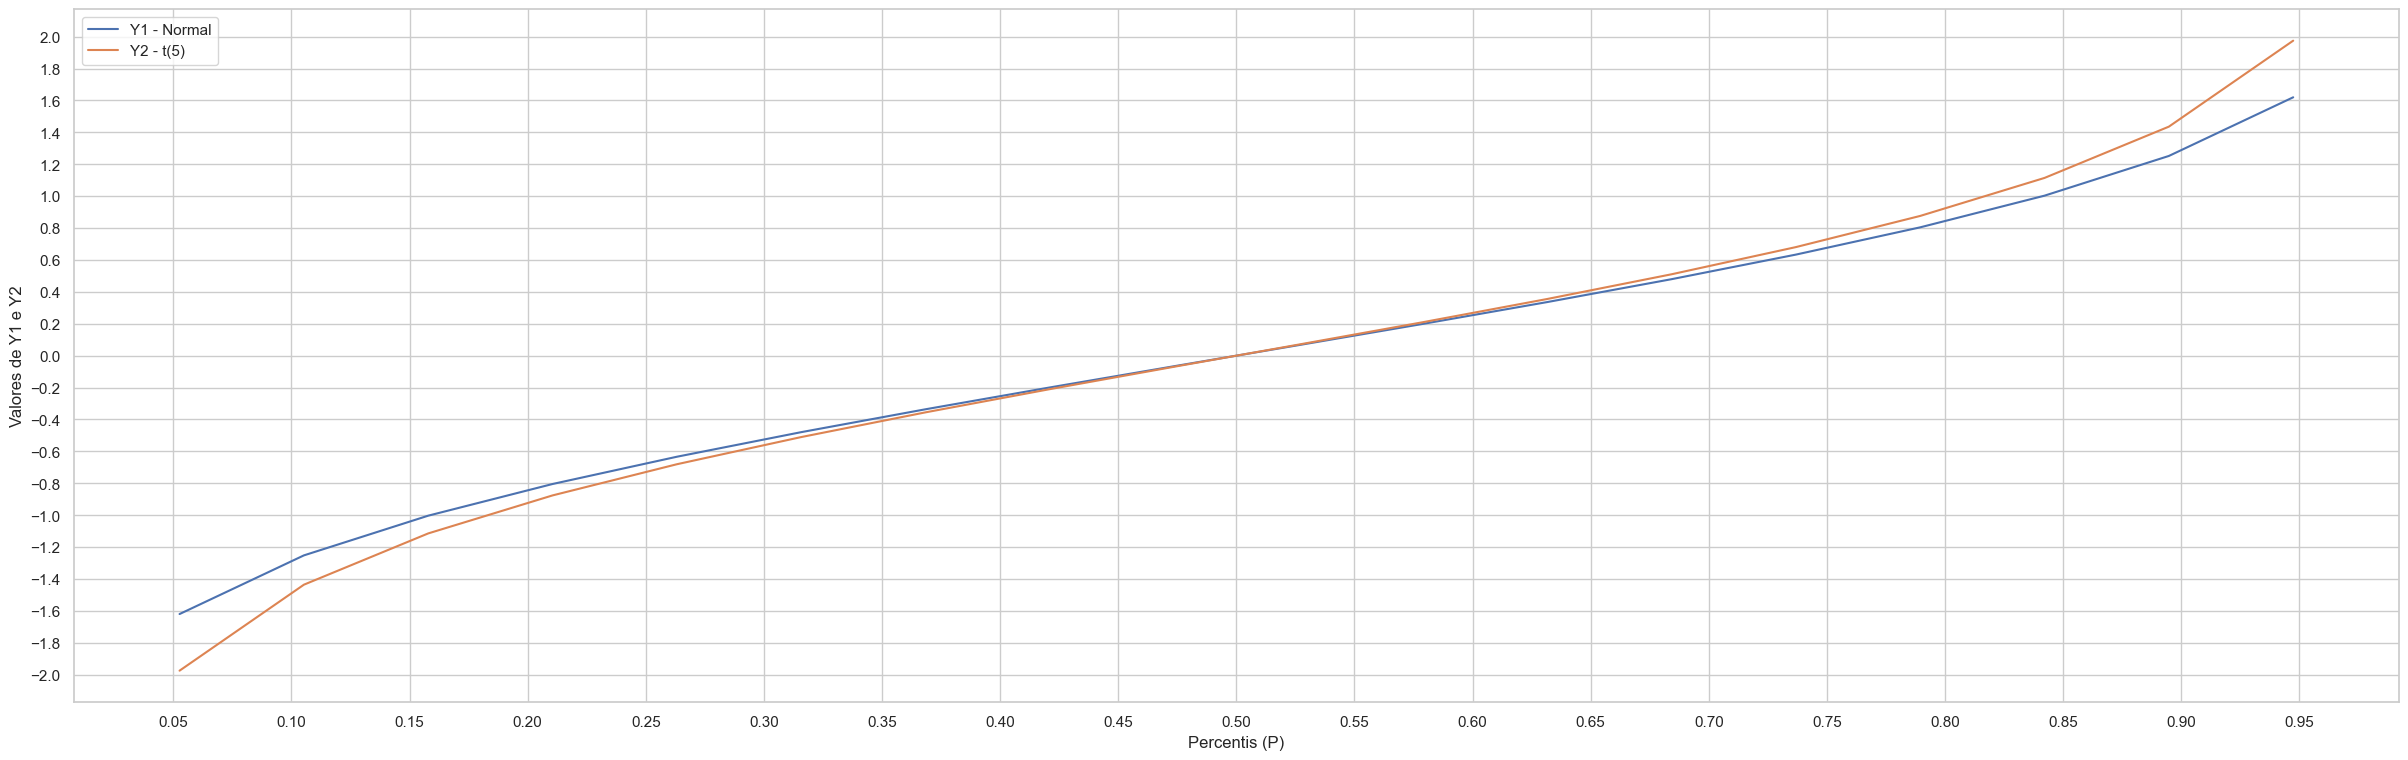

In [14]:
# Criação da figura e do eixo
fig, ax = plt.subplots(figsize=(30, 9))

# Plotagem dos dados de Y1 e Y2 em função dos percentis P
ax.plot(P, Y1, label='Y1 - Normal')
ax.plot(P, Y2, label='Y2 - t(5)')

# Configuração dos marcadores no eixo x e y
ax.xaxis.set_major_locator(plt.MaxNLocator(20))
ax.yaxis.set_major_locator(plt.MaxNLocator(22))

# Adição de rótulo para o eixo x indicando que são percentis
ax.set_xlabel('Percentis (P)')

# Adição de rótulo para o eixo y indicando que são valores de Y1 e Y2
ax.set_ylabel('Valores de Y1 e Y2')

# Adição da legenda
ax.legend()

# Exibição do gráfico
plt.show()

---